# The first approach to any EDA process is to understand the table content and structure

### Target tables:

- SalesOrderHeader: financial focuses on revenue, orders, dates and customers
- SalesOrderDetails: financial focuses in line items, products, quantities, prices
- Product: financial focuses on Products, prices and costs
- ProductCategory: focuses on product category
- ShipMethod: focuses on different means of transport

### these tables focuses on extracting potentional `human-centered` and `financial` insights for the business direct and indirect benefit
- it appears I would require more tables to extract real insights, the sheer value and scale of this database is both rich and massive, I underestimated time required to do so, whereby the sales section connect with product, customers, spatial data. thus the viable option is to add tables as needed to deliver a quality summary of generated insights

In [1]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from urllib.parse import quote_plus
from sqlalchemy import create_engine

load_dotenv()

db_user = os.getenv('DB_USER')
db_host = os.getenv('DB_HOST')
encoded_password = quote_plus(os.getenv('DB_PASSWORD'))
encoded_name = quote_plus(os.getenv('DB_NAME'))

connection_string = f'mysql+pymysql://{db_user}:{encoded_password}@{db_host}/{encoded_name}'
engine = create_engine(connection_string)

with engine.connect() as connection:
    
    # extracting salesorderheader table
    query_orderheader = 'SELECT * FROM `aw2022-sales-salesorderheader`'
    df_orderheader = pd.read_sql_query(query_orderheader, connection)

    # extracting salesorderdetails table
    query_orderdetails = 'SELECT * FROM `aw2022-sales-salesorderdetails`'
    df_orderdetails = pd.read_sql_query(query_orderdetails, connection)

    # extracting shipment method table
    query_shipment = 'SELECT * FROM `aw2022-purchasing-shipmethod`'
    df_shipment = pd.read_sql_query(query_shipment, connection)

    # extracting product table
    query_product = 'SELECT * FROM `aw2022-production-product`'
    df_product = pd.read_sql_query(query_product, connection)

    # extracting product category
    query_product_category = 'SELECT * FROM `aw2022-production-productcategory`'
    df_product_category = pd.read_sql_query(query_product_category, connection)

## A robust query design must:

- save sensitive variables in .env
- encode strings before reaching the DB connection string
- include a parameter dictionary as a guardrail against SQL injection
- align with business goals as to not overengineer the task and overcomplicate it

### for our case, we wouldn't include the third option as we are handling manual EDA and not an automated pipeline for a live service

In [2]:
df_orderheader.head(3)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CreditCardID,CreditCardApprovalCode,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,16281.0,105041Vi84182,NaN,20565.6206,1971.5149,616.0984,23153.2339,None,{79B65321-39CA-4115-9CBA-8FE0903E12E6},2011-06-07
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,5618.0,115213Vi29411,NaN,1294.2529,124.2483,38.8276,1457.3288,None,{738DC42D-D03B-48A1-9822-F95A67EA7389},2011-06-07
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,1346.0,85274Vi6854,4.0,32726.4786,3153.7696,985.5530,36865.8012,None,{D91B9131-18A4-4A11-BC3A-90B6F53E9D74},2011-06-07


In [3]:
df_orderheader.shape

(31465, 26)

In [4]:
df_orderheader.describe()

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,CustomerID,SalesPersonID,TerritoryID,BillToaddressID,ShipToAddressID,ShipMethodID,CreditCardID,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,ModifiedDate
count,31465.000000,31465.000000,31465,31465,31465,31465.0,31465.000000,3806.000000,31465.000000,31465.000000,31465.000000,31465.000000,30334.000000,13976.000000,31465.000000,31465.000000,31465.000000,31465.000000,31465
mean,59391.000000,8.000953,2013-08-21 11:43:49.321468,2013-09-02 11:44:14.034641,2013-08-28 11:44:14.034641,5.0,20170.175687,280.607987,6.090768,18263.154426,18249.192563,1.483839,9684.100448,9191.499571,3491.065673,323.755743,101.173693,3915.995109,2013-08-28 11:44:14.034641
min,43659.000000,8.000000,2011-05-31 00:00:00,2011-06-12 00:00:00,2011-06-07 00:00:00,5.0,11000.000000,274.000000,1.000000,405.000000,9.000000,1.000000,1.000000,2.000000,1.374000,0.109900,0.034400,1.518300,2011-06-07 00:00:00
25%,51525.000000,8.000000,2013-06-20 00:00:00,2013-07-02 00:00:00,2013-06-27 00:00:00,5.0,14432.000000,277.000000,4.000000,14080.000000,14063.000000,1.000000,4894.250000,8510.000000,56.970000,4.557600,1.424300,62.951900,2013-06-27 00:00:00
50%,59391.000000,8.000000,2013-11-03 00:00:00,2013-11-15 00:00:00,2013-11-10 00:00:00,5.0,19452.000000,279.000000,6.000000,19449.000000,19438.000000,1.000000,9719.500000,10074.000000,782.990000,62.639200,19.574800,865.204000,2013-11-10 00:00:00
75%,67257.000000,8.000000,2014-02-28 00:00:00,2014-03-13 00:00:00,2014-03-08 00:00:00,5.0,25994.000000,284.000000,9.000000,24678.000000,24672.000000,1.000000,14510.750000,11282.000000,2366.960000,189.597600,59.249300,2615.490800,2014-03-08 00:00:00
max,75123.000000,9.000000,2014-06-30 00:00:00,2014-07-12 00:00:00,2014-07-07 00:00:00,5.0,30118.000000,290.000000,10.000000,29883.000000,29883.000000,5.000000,19237.000000,12431.000000,163930.394300,17948.518600,5608.912100,187487.825000,2014-07-07 00:00:00
std,9083.307446,0.030864,NaN,NaN,NaN,0.0,6261.728960,4.846965,2.958119,8210.069158,8218.429263,1.304343,5566.299591,2945.170095,11093.452536,1085.054180,339.079427,12515.462713,NaN


In [5]:
df_orderheader.info()

<class 'pandas.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   SalesOrderID            31465 non-null  int64         
 1   RevisionNumber          31465 non-null  int64         
 2   OrderDate               31465 non-null  datetime64[us]
 3   DueDate                 31465 non-null  datetime64[us]
 4   ShipDate                31465 non-null  datetime64[us]
 5   Status                  31465 non-null  int64         
 6   OnlineOrderFlag         31465 non-null  str           
 7   SalesOrderNumber        31465 non-null  str           
 8   PurchaseOrderNumber     3806 non-null   str           
 9   AccountNumber           31465 non-null  str           
 10  CustomerID              31465 non-null  int64         
 11  SalesPersonID           3806 non-null   float64       
 12  TerritoryID             31465 non-null  int64         
 1

## it appears the next columns contain null values:

- `PurchaseOrderNumber`
- `SalesPersonID`
- `CreditCardID`
- `CreditCardApprovalCode`
- `CurrencyRateID`

In [6]:
for col, ratio in zip(df_orderheader.columns, df_orderheader.isna().mean()):
    if ratio == 0:
        continue
    else:
        print(f'{col}, null_ratio: {ratio*100:.2f}%')


PurchaseOrderNumber, null_ratio: 87.90%
SalesPersonID, null_ratio: 87.90%
CreditCardID, null_ratio: 3.59%
CreditCardApprovalCode, null_ratio: 3.59%
CurrencyRateID, null_ratio: 55.58%
Comment, null_ratio: 100.00%


## Generated insights from nan_ratios:
- 88% missing values in `SalePersonID` and `PurchaseOrderNumber` allows to define an intial assumption that 88% of sales transactions were online orders
- 4% in `CreditCardID` and `CreditCardApprovalCode` means that 4% of orders were paid using cash or other paying mediums whereby a massive ratio of 96% of transactions were paid using a credit card
    - it interestingly align with our first insight whom assumes 88% of sales were online orders, we will calculate the `OnlineFlagRatio` to confirm this assumption
- for the `CurrencyRateID` column, it appears that almost 56% of transactions happened in the local market (domestic), whereby almost 44% happened in internal or foreign markets

In [7]:
true, false = df_orderheader['OnlineOrderFlag'].value_counts()

true_ratio = true / (true + false)
print(f'online_orders_ratio: {true_ratio*100:.2f}%')

online_orders_ratio: 87.90%


- Online Orders Ratio: 87.90%
- Conclusion: Our previous assumption is true; the vast majority of transactions were online orders

### in Explatory Data Analysis some columns must be `dropped` as they hold 0 to low value in the process
##### we might try to save some Null records if the ratio of missing values are relatively low and can be propagated
- columns to be removed:
    - `Comment`: an empty column
    - `rowguid`: Global Unique Identifier, doesn't add value to the EDA step
    - `ModifiedData`: data entry's date of modification, doesn't add value
    - `CreditCardID`: sensitive data, doesn't hold any value to the EDA process
    - `CreditCardApproval`: sensitive data, doesn't contribute to the EDA process
- columns to be propagated:
    - None

In [8]:
columns_to_remove = ['Comment', 'rowguid', 'ModifiedDate', 'CreditCardID', 'CreditCardApprovalCode']
refined_df_orderheader = df_orderheader.drop(columns=columns_to_remove)

refined_df_orderheader.head()

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,SalesPersonID,TerritoryID,BillToaddressID,ShipToAddressID,ShipMethodID,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,279.0,5,985,985,5,NaN,20565.6206,1971.5149,616.0984,23153.2339
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,279.0,5,921,921,5,NaN,1294.2529,124.2483,38.8276,1457.3288
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,282.0,6,517,517,5,4.0,32726.4786,3153.7696,985.5530,36865.8012
3,43662,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43662,PO18444174044,10-4020-000227,...,282.0,6,482,482,5,4.0,28832.5289,2775.1646,867.2389,32474.9324
4,43663,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43663,PO18009186470,10-4020-000510,...,276.0,4,1073,1073,5,NaN,419.4589,40.2681,12.5838,472.3108


### at this step, the scope aimed to focus on aggregating Orders with higher transactions count and transactions sum, tracking and preparing to analyze customer behavior using unsupervised modeling techniques to build generative profiles
- it appears that we would need to track the customers whom placed these Orders to find the real insights, as it appears below a single transaction count per SalesOrderID represent a unique identifier per product defined by an automated system to track each unique order  
    - update: `CustomerID` was part of the table, that helped save time and helped switch the merge operation from `SalesOrderID` to `CustomerID`

In [9]:
salesorderID = refined_df_orderheader[['CustomerID','SalesOrderID', 'SubTotal']].copy()

Transaction_count_per_account = (
    refined_df_orderheader.groupby('CustomerID')['SubTotal']
    .count()
    .reset_index()
    .rename(columns={'SubTotal': 'Transactions_count'})
)

Transaction_total_per_account = (
    refined_df_orderheader.groupby('CustomerID')['SubTotal']
    .sum()
    .reset_index()
    .rename(columns={'SubTotal': 'Transactions_total'})
)

SalesID_df = pd.merge(Transaction_total_per_account, Transaction_count_per_account, on='CustomerID')

top_transactions_count = SalesID_df.sort_values(ascending=False, by='Transactions_count')
top_transactions_total = SalesID_df.sort_values(ascending=False, by='Transactions_total')

top_transactions_total.head(30)

,CustomerID,Transactions_total,Transactions_count
18818,29818,877107.1923,12
18715,29715,853849.1795,12
18722,29722,841908.7707,12
19117,30117,816755.5763,12
18614,29614,799277.8950,12
18639,29639,787773.0438,12
18701,29701,746317.5293,8
18617,29617,740985.8338,12
18994,29994,730798.7139,12
18646,29646,727272.6493,12


In [10]:
aggregated_summary = top_transactions_total[['Transactions_total', 'Transactions_count']].describe()
aggregated_summary

,Transactions_total,Transactions_count
count,19119.000000,19119.000000
mean,5745.404122,1.645745
std,38800.383348,1.457054
min,1.374000,1.000000
25%,54.980000,1.000000
50%,548.980000,1.000000
75%,2822.386050,2.000000
max,877107.192300,28.000000


In [11]:
print(f'highest paying customer: \n${top_transactions_total['Transactions_total'].max():.2f}\n\nlowest paying customer: \n${top_transactions_total['Transactions_total'].min():.2f}')

highest paying customer: 
$877107.19

lowest paying customer: 
$1.37


In [12]:
low_paying_customers_count = np.mean(top_transactions_count['Transactions_count'].head(30))
high_paying_customers_count = np.mean(top_transactions_total['Transactions_count'].head(30))

print(f'Transactions frequency count for the top 30 most low paying customers: \n{low_paying_customers_count:.2f}\n\nTransactions frequency count for the top 30 most high paying customers: \n{high_paying_customers_count:.2f}')

Transactions frequency count for the top 30 most low paying customers: 
21.37

Transactions frequency count for the top 30 most high paying customers: 
10.00


In [13]:
low_paying_customers_total = np.mean(top_transactions_count['Transactions_total'].head(30))
high_paying_customers_total = np.mean(top_transactions_total['Transactions_total'].head(30))

print(f'Transactions total spending average for the top 30 most low paying customers: \n${low_paying_customers_total:.2f}\n\nTransactions total spending average for the top 30 most high paying customers: \n${high_paying_customers_total:.2f}')

Transactions total spending average for the top 30 most low paying customers: 
$1029.53

Transactions total spending average for the top 30 most high paying customers: 
$671496.28


In [14]:
# low paying customers's Average Value per Order
low_p_customers_AOV = low_paying_customers_total / low_paying_customers_count

# high paying customers's Average Value per Order
high_p_customers_AOV = high_paying_customers_total / high_paying_customers_count

print(f'Transaction cost per order for the top 30 most low paying customers: \n${low_p_customers_AOV:.2f}\n\nTransaction cost per order for the top 30 most high paying customers: \n${high_p_customers_AOV:.2f}')

Transaction cost per order for the top 30 most low paying customers: 
$48.18

Transaction cost per order for the top 30 most high paying customers: 
$67149.63


- it appears that top_30 customers with lower transaction total sum have more than double frequency that of the top_30 high paying customers, outliers exist but the patterns are real:
    - on average, transaction count for top_30 low paying customers ~= 21 transactions, with an average total transaction cost of approximately **$1030**
        - transaction cost per order for low paying customers is approximately **$48**
    - on average, transactions count for top_30 high paying customers ~= 10 transactions, with an average total transaction cost of approximately **$671496**
        - transaction cost per order for high paying customers is approximately **$67150**

- this is but an initial approach, as this calculation introduces bias which might impact insight quality, We planned to manually categories customers based on certain thresholds which requires dropping outliers (which might represent our most important customers), furthermore using Gaussian Mixture Model with a full covariance respect the variation of these customers in comparison to DBSCAN which might fail to capture these outliers

#### before proceeding to the unsupervised modeling layer, we are going to confirm our claim about outlier existance

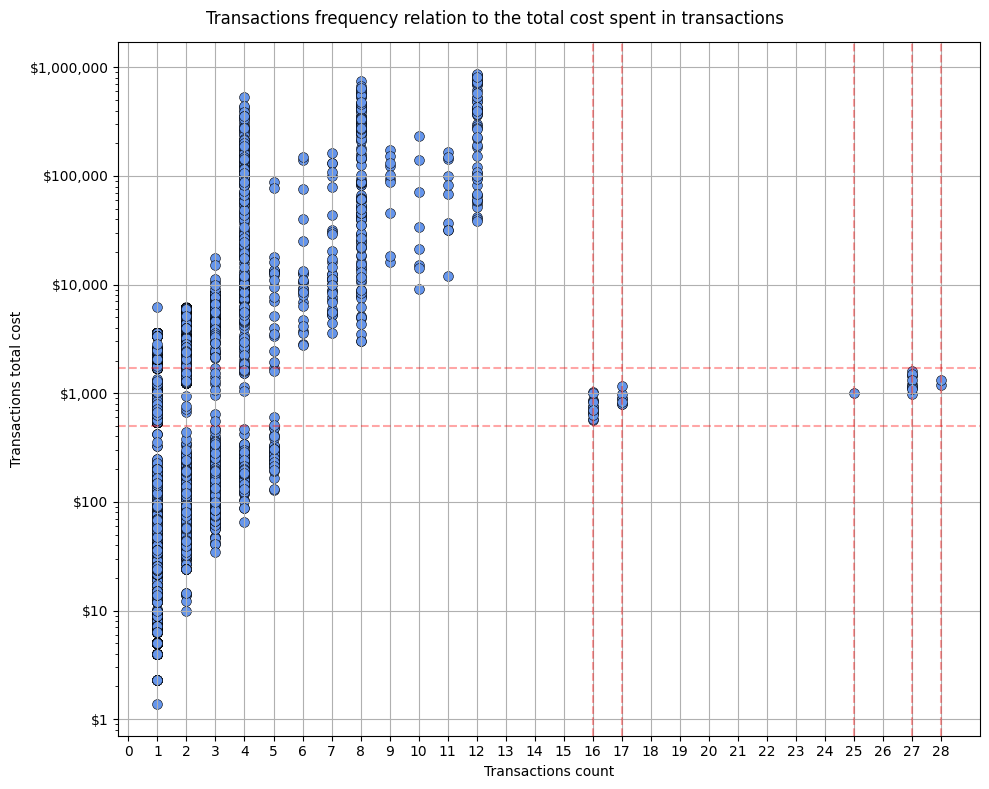

In [15]:
import matplotlib.ticker as ticker

x_sales = SalesID_df['Transactions_count']
y_sales = SalesID_df['Transactions_total']

plt.figure(figsize=(10, 8))

plt.scatter(x_sales, y_sales,
            s=50,
            linewidth=0.4,
            color='cornflowerblue',
            edgecolors='k')

plt.suptitle('Transactions frequency relation to the total cost spent in transactions')
plt.xlabel('Transactions count')
plt.ylabel('Transactions total cost')

# changed the scale into a logarithmic scale, so that y-axis won't dominate the difference between it and the x-axis
plt.yscale('log')

# changed the scientific notation into clear financial notations instead
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
plt.xticks(np.arange(0, 29, 1))

x_cords=[16, 17, 25, 27, 28]
y_cords=[500, 1700]

for x_line in x_cords:
    plt.axvline(x=x_line,
                color='red',
                linestyle='--',
                alpha=0.35)
    
for y_line in y_cords:
    plt.axhline(y=y_line,
                color='red',
                linestyle='--',
                alpha=0.35)

plt.tight_layout()
plt.grid(True)
plt.show()

In [16]:
hypothesis_validation = top_transactions_total[(top_transactions_total['Transactions_count'] >= 16) & (top_transactions_total['Transactions_count'] <= 28)]
hypothesis_validation['Transactions_total'].describe()

count      35.000000
mean      985.743429
std       280.016554
min       561.530000
25%       775.410000
50%       980.770000
75%      1161.295000
max      1616.310000
Name: Transactions_total, dtype: float64

- the scale between the y-axis and x-axis is vast, the proper approach is to plot the y-axis in logarithmic scale, then format the numerical objects in the y-axis from scientific to financial notation
- this exact visualization proves the existance of outliers, and furthermore proves that **Gaussian Mixture Model** with **full** covariance type is the right approach for the clustering process
    - optional: instead of using **StandardScaler** we might apply logarithmic scaling for GMM to fix the big interval between outliers and normal data points in our RFM subset, the utilization of **Full** was to handle multicollinearity using the inverse matrix with different segements shape, and is highly sensitive to outliers (aiming to use reg_covar to account for extreme outliers and difficult data structure)
> it appears that customers with `Transactions_count` = (16, 17, 25, 27, 28) are outliers, they won't be dropped but rather further prove that GMM is the right tool for this task
- furthermore, following the aggregated_summary output, it is visible that limiting the analysis to top 30 most paying and top 30 least paying costumers was a biased practice from my part and further assesses the need for GMM with `full` covariance type
- the x-axis *axvline* was used to track these outliers's transactions purchase frequence, while *axhline* was to track the transaction cost interval for these outliers, the above summary confirm the visualization cost interval for specific transactions count as in customers with a `Transaction_count` >= **16** have a Transaction cost between ~= **$500** and **$1700** with an average spending of ~= **$986**

In [17]:
# so total customers detected as outliers are 35
outlier_customers = hypothesis_validation.shape[0]

# total customers in the dataset are 19k
total_customers = top_transactions_total.shape[0]

outlier_customers_portion = f'{(outlier_customers / total_customers)*100:.2f}%'
outlier_customers_portion

'0.18%'

In [18]:
outlier_customers_transactions_sum = hypothesis_validation['Transactions_total'].sum()
total_transactions_sum = top_transactions_total['Transactions_total'].sum()

outlier_customers_transactions_portion = f'{(outlier_customers_transactions_sum / total_transactions_sum)*100:.2f}%'
outlier_customers_transactions_portion

'0.03%'

> these extreme outliers transactions represent about **0.18%** of total customers, suggesting that they hold no critical value to the business model, but still they hold a total of **$34501** in transaction total, representing **0.03%** of all customer transactions, but still **$34501** is still a portion that cannot be ignored if possible, further supporting the need for **GMM**

In [19]:
# calculating the taxratio before freight cost
refined_df_orderheader['TaxRatio%'] = np.round(refined_df_orderheader['TaxAmt'] / (refined_df_orderheader['SubTotal'] + refined_df_orderheader['TaxAmt'])*100, 2)

# calculating freight ratio from `TotalDue` for further analysis
refined_df_orderheader['FreightBurden%'] = np.round(refined_df_orderheader['Freight'] / (refined_df_orderheader['SubTotal'] + refined_df_orderheader['Freight']) * 100, 2)

refined_df_orderheader.head(3)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,BillToaddressID,ShipToAddressID,ShipMethodID,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,TaxRatio%,FreightBurden%
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,985,985,5,NaN,20565.6206,1971.5149,616.0984,23153.2339,8.75,2.91
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,921,921,5,NaN,1294.2529,124.2483,38.8276,1457.3288,8.76,2.91
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,517,517,5,4.0,32726.4786,3153.7696,985.5530,36865.8012,8.79,2.92


In [20]:
refined_df_orderheader['SubTotal'].describe()

count     31465.000000
mean       3491.065673
std       11093.452536
min           1.374000
25%          56.970000
50%         782.990000
75%        2366.960000
max      163930.394300
Name: SubTotal, dtype: float64

### the creation of `TaxRatio%` urge the need for more geographic data, as it appears although some subtotals are low on average yet with higher tax than much larger subtotal values
- further analysis in shipment interval can be considered as indirect cause of tax increase
- further spatial data needed to evaluate a more accurate description of tax differentiation
- perhaps low subtotal have a higher tax rate on average, or different market static taxes regardless of such, we will proceed to confirm this assumption

### we will start with the first hypothesis as to confirm if low subtotal shipments have a greater taxratio on average than bigger subtotal shipments

In [21]:
min_val = refined_df_orderheader['SubTotal'].min()
max_val = refined_df_orderheader['SubTotal'].max()

q1 = refined_df_orderheader['SubTotal'].quantile(0.25)
q3 = refined_df_orderheader['SubTotal'].quantile(0.75)

categorized_labels = ['Low', 'Medium', 'High']
cohort_bins = [min_val, q1, q3, max_val]

# categorizing `SubTotal` costs into three categories to build the support our hypothesis
refined_df_orderheader['SubTotalCategorized'] =  pd.cut(refined_df_orderheader['SubTotal'],
                                        bins=cohort_bins,
                                        labels=categorized_labels,
                                        include_lowest=True)

refined_df_orderheader.head(3)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,ShipToAddressID,ShipMethodID,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,TaxRatio%,FreightBurden%,SubTotalCategorized
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,985,5,NaN,20565.6206,1971.5149,616.0984,23153.2339,8.75,2.91,High
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,921,5,NaN,1294.2529,124.2483,38.8276,1457.3288,8.76,2.91,Medium
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,517,5,4.0,32726.4786,3153.7696,985.5530,36865.8012,8.79,2.92,High


In [22]:
summary_subtotal_average = refined_df_orderheader.groupby('SubTotalCategorized')['TaxRatio%'].mean()

summary_subtotal_average

SubTotalCategorized
Low       7.423910
Medium    7.503807
High      7.907203
Name: TaxRatio%, dtype: float64

In [23]:
subset_count = refined_df_orderheader.groupby('SubTotalCategorized')['SubTotal'].count()
total_number_customers = subset_count.sum()

Low_SubTotal_Ratio = f'Low_p_customers: {subset_count['Low'] / (total_number_customers)*100:.2f}%'
Medium_SubTotal_Ratio = f'Medium_p_customers: {subset_count['Medium'] / (total_number_customers)*100:.2f}%'
High_SubTotal_Ratio = f'High_p_customers: {subset_count['High'] / (total_number_customers)*100:.2f}%'

categorized_ratio = [Low_SubTotal_Ratio, Medium_SubTotal_Ratio, High_SubTotal_Ratio]
print(categorized_ratio)

['Low_p_customers: 25.26%', 'Medium_p_customers: 49.79%', 'High_p_customers: 24.95%']


In [24]:
total = subset_count.sum()
percentages = (subset_count / total) * 100

percentages

SubTotalCategorized
Low       25.259812
Medium    49.788654
High      24.951533
Name: SubTotal, dtype: float64

- the previous cell output indicates a sample imbalance, the common feedback might be to propagate the `Low` and `High` categories or scale down the `Medium` category to balance the calculation conclusion in cell below, but I think personally that removing such is an even more biased action toward real behaviors of customer transactions, thus why leaving the mismatch as is and interpreting it is a more fair approach
- by utilizing the ouput of `categorized_ratio` we notice and interesting pattern, `Low_p_customers` and `High_p_customers` equal ~ 25% while the `Medium_p_customers` equal ~ 50%, looking at this our data follows a beautiful bell curve centered at the middle with natural tails

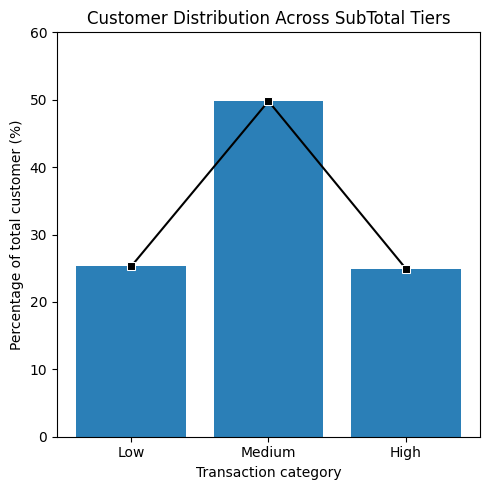

In [25]:
import seaborn as sns

plt.figure(figsize=(5, 5))

order = ['Low', 'Medium', 'High']
plot_df = percentages.reset_index(name='Percentages')

sns.barplot(data=plot_df,
                x='SubTotalCategorized',
                y='Percentages',
                order=order,
                color="#1484ce")

# second plot to showcase the variance between the plots
sns.lineplot(data=plot_df,
            x='SubTotalCategorized',
            y='Percentages',
            color='k',
            marker='s')

plt.title('Customer Distribution Across SubTotal Tiers')
plt.ylabel('Percentage of total customer (%)')
plt.xlabel('Transaction category')

plt.ylim(0, 60) # breathing room for the distribution

plt.tight_layout()
plt.show()

> the visualization confirms customer transaction distribution using the quantile approach

In [26]:
refined_subset = refined_df_orderheader[['SubTotal', 'TaxRatio%']]
refined_subset.corr()

,SubTotal,TaxRatio%
SubTotal,1.000000,0.513756
TaxRatio%,0.513756,1.000000


> the hypothesis that transactions with low `SubTotal` have a higher average `TaxRatio%` than transactions with higher `TaxRatio%` is proven false, matter of fact it is in the opposite direction, reflecting that `TaxRatio%` increases as transaction `SubTotal` increase, furthermore the correlation matrix indicates that a correlation strenght ~= 51% represent a moderate linear correlation between both, as a correlation above 50% in real-world transactions indicates a strong underlying pattern

- Calculating the time interval between `OrderDate`, `ShipDate` and `DueDate` to support further hypothesis validation

In [27]:
temp_view = refined_df_orderheader[['OrderDate', 'DueDate', 'ShipDate']]

temp_view.head(5)

,OrderDate,DueDate,ShipDate
0,2011-05-31,2011-06-12,2011-06-07
1,2011-05-31,2011-06-12,2011-06-07
2,2011-05-31,2011-06-12,2011-06-07
3,2011-05-31,2011-06-12,2011-06-07
4,2011-05-31,2011-06-12,2011-06-07


- for the original table in **MySQL** Database, it appears that the values follows this format `xx-xx-xx` but for the timestamps it follows the same `00:00:00` value, as it appear from now on we can rest assured and focus on dates instead

In [28]:
# Normalizing Dtypes from timedelta64 into datetime
refined_df_orderheader['ShipDate'] = pd.to_datetime(refined_df_orderheader['ShipDate'])
refined_df_orderheader['OrderDate'] = pd.to_datetime(refined_df_orderheader['OrderDate'])
refined_df_orderheader['DueDate'] = pd.to_datetime(refined_df_orderheader['DueDate'])

# omitting the 'days' and leaving the values as integers
refined_df_orderheader['TimeInterval_ship'] = (
    refined_df_orderheader['ShipDate'] - refined_df_orderheader['OrderDate']
    ).dt.days

refined_df_orderheader['TimeInterval_due'] = (
    refined_df_orderheader['DueDate'] - refined_df_orderheader['OrderDate']
    ).dt.days

# doesn't require .dt.days as we already handled it in previous the previous calculations
refined_df_orderheader['BufferTime'] = refined_df_orderheader['TimeInterval_due'] - refined_df_orderheader['TimeInterval_ship']

# copied the subset using .copy() as each time this subset is modified it appears that it confuses pandas,
# pandas isn't sure if you aim to alter this subset or the original dataframe.
time_interval_summary = refined_df_orderheader[['TimeInterval_ship', 'TimeInterval_due', 'BufferTime', 'TaxRatio%']].copy()

time_interval_summary.head(3)

,TimeInterval_ship,TimeInterval_due,BufferTime,TaxRatio%
0,7,12,5,8.75
1,7,12,5,8.76
2,7,12,5,8.79


In [29]:
time_interval_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TimeInterval_ship  31465 non-null  int64  
 1   TimeInterval_due   31465 non-null  int64  
 2   BufferTime         31465 non-null  int64  
 3   TaxRatio%          31465 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 983.4 KB


#### testing correlation strenght between `taxratio` and other selective features

In [30]:
correlation_matrix = time_interval_summary.corr()['TaxRatio%']

correlation_matrix

TimeInterval_ship    0.002025
TimeInterval_due     0.002025
BufferTime                NaN
TaxRatio%            1.000000
Name: TaxRatio%, dtype: float64

- it appeared, that `TimeInterval_ship` and `TimeInterval_due` doesn't correlate with `TaxRatio%` increase, we also notice that `BufferTime` returned **NaN**

In [31]:
for i in time_interval_summary['BufferTime'].unique():
    print(i)

5


In [32]:
np.var(time_interval_summary['BufferTime'])

np.float64(0.0)

### Operational Insight: Uniform Logistics Execution Across Tax zones:
- Finding: Statistical correlation between `BufferTime` and `TaxRatio` returned **NaN**, driven by total absense in the variance in the buffer window, with a single outlier of **5 days** in 31,465 transactions
- Conclusion: Fullfillment scheduling is entirely uniform. Regional tax rates differences has no impact on delivery expectation and logistics timeline

### Let's visualize the correlation matrix in our target table

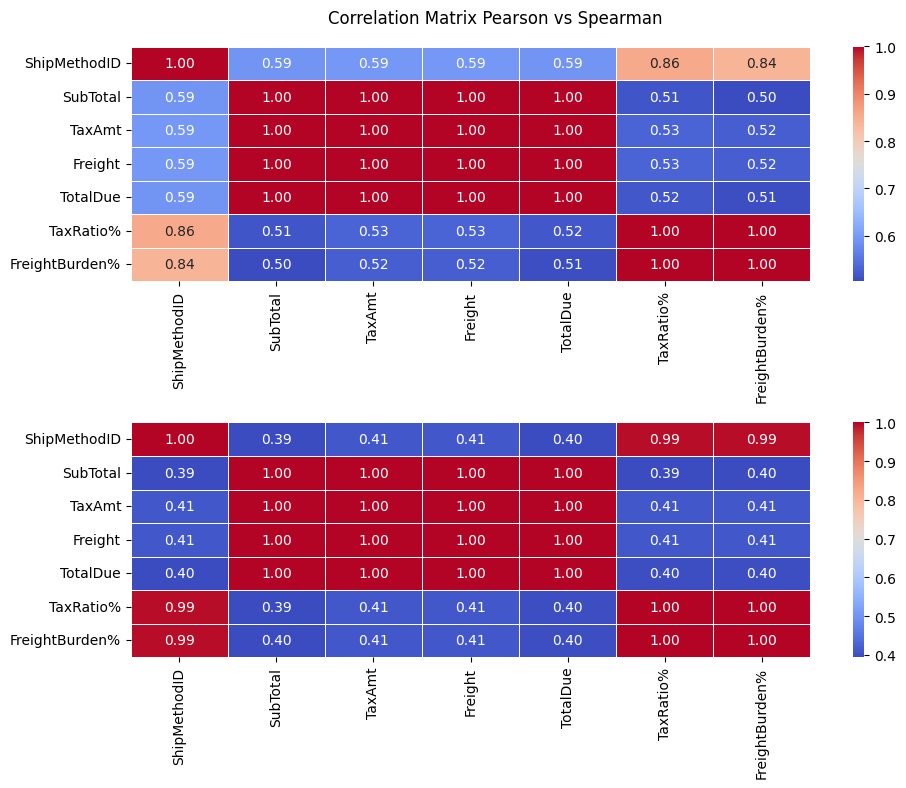

In [33]:
import seaborn as sns

temp_table = refined_df_orderheader.drop(columns=['OrderDate', 'DueDate', 'ShipDate', 'PurchaseOrderNumber', 'AccountNumber',
                                                'RevisionNumber', 'OnlineOrderFlag', 'SalesOrderNumber', 'SubTotalCategorized',
                                                'Status', 'BufferTime', 'SalesOrderID', 'TimeInterval_ship', 'TimeInterval_due',
                                                'BillToaddressID', 'ShipToAddressID', 'SalesPersonID', 'TerritoryID',
                                                'CurrencyRateID', 'CustomerID']) # doesn't add much weight to the correlation strength

# pearson coefficient correlation matrix
corr_matrix_pearson = temp_table.corr(method='pearson')

# spearman coefficient correlation matrix
corr_matrix_spearman = temp_table.corr(method='spearman')

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

sns.heatmap(corr_matrix_pearson,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidth=0.4,
            ax=ax[0])

sns.heatmap(corr_matrix_spearman,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidth=0.4,
            ax=ax[1])

plt.suptitle('Correlation Matrix Pearson vs Spearman')

plt.tight_layout()
plt.show()

In [34]:
from scipy import stats

# seperating ShipMethod's FreightBurden% into two groups for a statistical test
group_1_freight = refined_df_orderheader[refined_df_orderheader['ShipMethodID'] == 1]['FreightBurden%']
group_5_freight = refined_df_orderheader[refined_df_orderheader['ShipMethodID'] == 5]['FreightBurden%']

group_1_tax = refined_df_orderheader[refined_df_orderheader['ShipMethodID'] == 1]['TaxRatio%']
group_5_tax = refined_df_orderheader[refined_df_orderheader['ShipMethodID'] == 5]['TaxRatio%']

# using a non-parametric two-sample and two-tails test as an alternative to t-test without assumption data distribution
stat_freight, p_value_freight = stats.mannwhitneyu(group_1_freight, group_5_freight, alternative='two-sided')
if p_value_freight < 0.05:
    print('Significant difference, Shipment 1 and 5 have different freight burden')
else:
    print('No significant difference between the two shipment types')

# using the same approach but to validate the weight of TaxRatio% groups difference significance
stat_tax, p_value_tax = stats.mannwhitneyu(group_1_tax, group_5_tax, alternative='two-sided')
if p_value_tax < 0.05:
    print('Significant difference, Shipment 1 and 5 have different tax ratios')
else:
    print('No significant difference between the two shipment types')

Significant difference, Shipment 1 and 5 have different freight burden
Significant difference, Shipment 1 and 5 have different tax ratios


In [35]:
features = ['SubTotal', 'TaxAmt', 'Freight', 'TotalDue']
cov_matrix_4d = refined_df_orderheader[features].cov().values

# Compute eigenvalues
eigenvalues, _ = np.linalg.eig(cov_matrix_4d)

# Sort eigenvalues from largest to smallest
eigenvalues = sorted(eigenvalues, reverse=True) # eigenvalues represent the total explain variance for each component (where each component is a set of feature coefficients and data points)

for i, val in enumerate(eigenvalues):
    component_ratio = (val / sum(eigenvalues))
    print(f'Component{i}, ExplainedVariance: {component_ratio*100:.3f}%')

Component0, ExplainedVariance: 99.998%
Component1, ExplainedVariance: 0.002%
Component2, ExplainedVariance: 0.000%
Component3, ExplainedVariance: -0.000%


- previously we calculated `TaxRatio%` of `TotalDue` without `FreightBurden%`, yet it appears they perfectly correlate in this visualization, and the reason behind such is both calculations relied on `SubTotal` as baseline to reach the cost ratio to TotalDue, even the original features confirm such with a perfect 1.00 correlation, they are suggesting multicollinearity existance, thus why using them only to explain `ShipMetodID` is a better approach
- `SubTotal`, `TaxAmt`, `Freight` and `TotalDue` suffer from multicollinearity between each other, suggesting that their variations moves in perfect synchrony (the rate of change between features is in almost perfect harmony)
> look at the output of `eigenvalues` components ratio, indeed it means our features covariance synchronize by 99.998% of the time, explaining why we see a perfect 1.00 correlation between the 4 features
- look at `ShipMethodID` groups significance with `TaxRatio%` and `FreightBurden%` we conclude that different shipmentmethods impact `FreightBurden%` and `TaxRatio%` directly, using the non-parametric two-sample and two-tailed test such as **Mann-Whitney U test** to spot any significance between the two groups, since **ShipMethodID** follows a nominal numerical data structure, it is appropriate here to use this test, then use pearson or spearman coefficient matrix

In [73]:
refined_ship_method = df_shipment.drop(columns=['rowguid', 'ModifiedDate'])
overhead_subset = refined_df_orderheader[['ShipMethodID', 'TaxRatio%', 'FreightBurden%']]

refined_ship_method.drop_duplicates(inplace=True)
refined_ship_method

,ShipMethodID,Name,ShipBase,ShipRate
0,1,XRQ - TRUCK GROUND,3.95,0.99
1,2,ZY - EXPRESS,9.95,1.99
2,3,OVERSEAS - DELUXE,29.95,2.99
3,4,OVERNIGHT J-FAST,21.95,1.29
4,5,CARGO TRANSPORT 5,8.99,1.49


In [81]:
shipment_category_subset = pd.merge(refined_ship_method, overhead_subset, on='ShipMethodID')

shipment_category_subset.head(5)

,ShipMethodID,Name,ShipBase,ShipRate,TaxRatio%,FreightBurden%
0,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44
1,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44
2,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44
3,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44
4,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44


In [109]:
# ShipRate represent act as a booking fee to intialize product intention of placement in the transporting medium
# ShipBase represent is the product measure factor multiplier like weight, length or volume or all combined

shipment_cols = ['ShipBase', 'ShipRate', 'TaxRatio%', 'FreightBurden%']

# switch between 1 (Ground trucks) and 5 (transport cargo) inside the loop the see different outputs whom support the generated insight below 
for i in shipment_cols:
    unique_output = shipment_category_subset[shipment_category_subset['ShipMethodID'] == 1][i].unique()
    print(f'{i}, unique_values: {unique_output}')

ShipBase, unique_values: [3.95]
ShipRate, unique_values: [0.99]
TaxRatio%, unique_values: [7.41]
FreightBurden%, unique_values: [2.44]


> look at this beauty, using Ground trucks as medium of transportation (Domestic market) reflect 0 variation in all 4 features in `shipment_cols`, whereby when using the transport cargo as transport medium, it further assess the variation of `FreigthBurden%` and `TaxRate%` beautifully explain the rate of change of taxes for different foreign markets

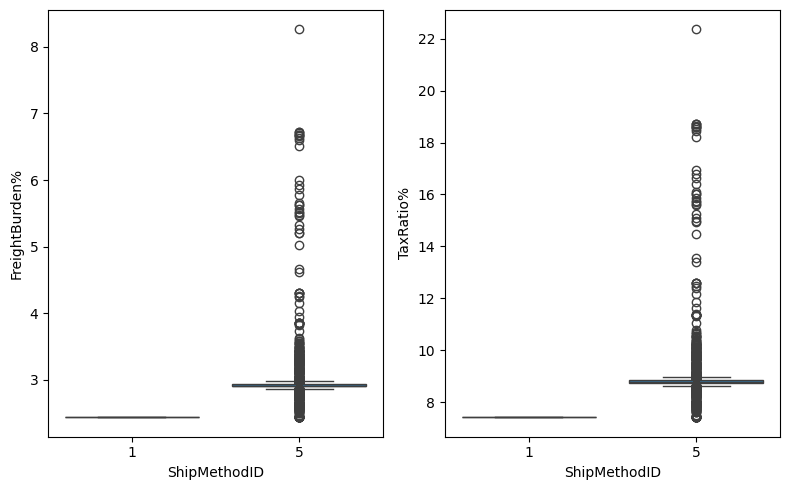

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x='ShipMethodID',
            y='FreightBurden%',
            data=refined_df_orderheader,
            ax=ax[0])

sns.boxplot(x='ShipMethodID',
            y='TaxRatio%',
            data=refined_df_orderheader,
            ax=ax[1])

plt.tight_layout()
plt.show()

In [76]:
refined_df_orderheader['ShipMethodID'].value_counts()

ShipMethodID
1    27659
5     3806
Name: count, dtype: int64

In [77]:
shipment_count = refined_df_orderheader['ShipMethodID'].value_counts()
shipment_ratio = np.round((shipment_count.loc[5] / (shipment_count.loc[5] + shipment_count.loc[1]))*100, 2)

print(f'ShipMethodID=5_shipment_ratio: {shipment_ratio}%\nShipmentMethodID=1_shipment_ratio: {100 - shipment_ratio}%')

ShipMethodID=5_shipment_ratio: 12.1%
ShipmentMethodID=1_shipment_ratio: 87.9%


#### ~12.1% of product shipment in `ShipMethodID` are **Transport Cargo**, while a ~87.9% of product shipment are **transport ground trucks type XQR** (we will map this by merging the `shipmethod`), regarding the visualization and taking the imbalanced sampling insight, we reached some insights with Gemini acting as a peer auditor for our analysis quality:
- **Group 1 is a fixed-rate rule**: relies on Ground truncks for products transport Serves as the primary operational backbone. It features absolute zero variance, operating under a rigid, corporate flat-rate pricing matrix designed to streamline high-volume domestic movements.
- **Group 2 is a dynamic-rate rule**: Handles irregular, heavy-duty, or cross-border cargo. This method exhibits a severe right-hand skew and extreme upward outliers (up to 22%), absorbing the volatile expenses of international tariffs, transport distances, and foreign market infrastructure
> within the 57% range, 56% of product transactions are domestic account for 87.9% of our transportation fleet using ground trunks, while 44% product transactions in the foreign market utilize the remaining 12.1% transport cargo as a medium of transporting the products to the foreign market

- but I noticed that we only relied on two mediums `ShipMethodID(1 and 5)` representing ground trucks and transport cargos, yet the remaining mediums such as **'ZY - EXPRESS'**, **'OVERSEAS - DELUXE'**, **'OVERNIGHT J-FAST'** are not being utilized, perhaps the 2 mediums are more than enough for the task

### preparing `refined_df_product`, `refined_df_product_category` and `df_orderdetails` table for cross-analysis with `product_track`

In [41]:
refined_df_product_category = df_product_category.drop(columns=['rowguid', 'ModifiedDate'])

In [42]:
refined_df_product = df_product.drop(columns=['ModifiedDate', 'rowguid'])
refined_df_product.head(1)

,ProductID,Name,ProductNumber,MakeFlag,FinishedGoodsFlag,Color,SafetyStockLevel,ReorderPoint,StandardCost,ListPrice,...,Weight,DaysToManufacture,ProductLine,Class,Style,ProductSubcategoryID,ProductModelID,SellStartDate,SellEndDate,DiscontinuedDate
0,1,Adjustable Race,AR-5381,False,False,NaN,1000.0,750.0,0.0,0.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2008-04-30,NaT,None


In [43]:
empty_cols = []
consistant_ratio_cols = []

for col, null_ratio in zip(refined_df_product.columns, refined_df_product.isna().mean()):
    if null_ratio == 0:
        continue

    null_ratio_normalized = null_ratio*100
        
    if 42 <= null_ratio_normalized <= 43:
        consistant_ratio_cols.append((col, f'null_ratio: {null_ratio_normalized:.2f}'))

    elif null_ratio_normalized < 100:
        print(f'{col}, null_ratio: {null_ratio_normalized:.2f}%')

    else:
        empty_cols.append((col, null_ratio_normalized))

Color, null_ratio: 91.67%
Size, null_ratio: 99.80%
WeightUnitMeasureCode, null_ratio: 94.25%
Weight, null_ratio: 94.25%
ProductLine, null_ratio: 87.30%
Class, null_ratio: 85.91%
Style, null_ratio: 99.80%
ProductSubcategoryID, null_ratio: 83.93%
ProductModelID, null_ratio: 83.93%
SellEndDate, null_ratio: 94.84%


In [44]:
empty_cols

[('SizeUnitMeasureCode', 100.0), ('DiscontinuedDate', 100.0)]

> 100% empty records in `DiscontinuedDate` would suggest that all deployed products are still active or under R&D, development to align with the business model expectations
- `SizeUnitMeasureCode` represents the product's measurement type, with Gemini support (A Large Language Model serving as the best peer auditor and collaborator to this process), we concluded that the products are sold without regarding the measurement factor to calculate different costs, which interestingly means we would safely eliminate this factor from our freightburden hypothesis task
- `SellEndDate` with ~95% null_ratio, this pattern suggest that 5% of products were retired and replaced or upgraded to fit the business vision
- an aproximately 43% null_ratio in `SellStartDate` indicates that approximately 57% of products are (active to close-to-active) for customers market, while 43% of products are still under evaluation, testing or refinement to fit business model vision
- very interesting, look at `Name`, `ProductNumber`, `MakeFlag`, `FinishedGoodFlag`, `SafetyStockLevel`, `ReorderPoint`, `StandardCost`, `ListPrice`, `StandardCost`, `ListPrice`, `DaysToManufacture` are more than enough factors to prove that `SellEndDate` assumption is true, as `FinishedGoodsFlag`, **prices**, and `DayToManufacture` consistency in ~43% in null_ratio indicate that 43% of products are still under evaluation, testing and refinement to fit the business model vision
    - if we dig deeper into `StandardCost` and `ListPrice` we see placeholders following this format: **0.000** for `StandardCost` and **0.00** for `ListPrice`, furthermore taking these patterns we can assume that ~43% represent a ratio of products under evaluation, testing and refinement, as for the remaining 57% active products, our best current conclusion is that products with the placeholders ~=39.68% are close to be active products into the customer markets, whereby the remaining non_placeholder non_null value which represent ~= 17.86% as the real active fully commercial product integrated into the customer market, and the cells ouput below confirms the claims
- when we mapped `FinishedGoodsFlag` within the category of 57% (active to close-to-active category), ~=27.93% are finished products where a greater ratio of unfinished products equal 72.07% within this active category, taking the previous ~=17.86% fully operational and active products and the ~=27.93% of finished products that would mean 10.07% of our finished products are not active
> for this claim  *for the `CurrencyRateID` column, it appears that almost 56% of transactions happened in the local market (domestic), whereby almost 44% happened in internal or foreign markets*, highlight that both domestic and foreign market transactions are within the 57% range and that of course within the 17.86% of fully operational and commercial product section
- `Weight` and `WeightUnitMeasureCode` null_ratio ~=95% indicates that only ~=5% of the products are being evaluated with the weight factor in mind, and the weight factor doesn't respecte the state of the product neither active and finished or unactive and finished are direct reasons to explain for the weight factor utilization

In [45]:
consistant_ratio_cols

[('Name', 'null_ratio: 42.46'),
 ('ProductNumber', 'null_ratio: 42.46'),
 ('MakeFlag', 'null_ratio: 42.46'),
 ('FinishedGoodsFlag', 'null_ratio: 42.46'),
 ('SafetyStockLevel', 'null_ratio: 42.46'),
 ('ReorderPoint', 'null_ratio: 42.46'),
 ('StandardCost', 'null_ratio: 42.46'),
 ('ListPrice', 'null_ratio: 42.46'),
 ('DaysToManufacture', 'null_ratio: 42.46'),
 ('SellStartDate', 'null_ratio: 42.46')]

In [46]:
placeholder_count = refined_df_product[refined_df_product['StandardCost'] == 0].shape[0]
placeholder_ratio = f'placeholder_ratio: {(placeholder_count / refined_df_product.shape[0])*100:.2f}%'

placeholder_ratio 

'placeholder_ratio: 39.68%'

In [47]:
active_function_product_count = refined_df_product[(refined_df_product['StandardCost'] != 0) & (refined_df_product['StandardCost'].notna())].shape[0]
active_function_product_ratio = f'active_product_ratio: {(active_function_product_count / refined_df_product.shape[0])*100:.2f}%'

active_function_product_ratio

'active_product_ratio: 17.86%'

In [48]:
safety_lock_check = f'active_product_safety_check: {refined_df_product['SafetyStockLevel'].notna().mean()*100:.2f}%'
ReorderPoint = f'ReorderPoint_ratio: {refined_df_product['ReorderPoint'].notna().mean()*100:.2f}%'

FinishedProductCount = refined_df_product['FinishedGoodsFlag'].value_counts()

active_function_p_ratio = active_function_product_count / refined_df_product.shape[0]
placeholder_p_ratio = placeholder_count / refined_df_product.shape[0]

print(f'active_product_ratio: {(active_function_p_ratio + placeholder_p_ratio)*100:.2f}%\n{safety_lock_check}\n{ReorderPoint}')

active_product_ratio: 57.54%
active_product_safety_check: 57.54%
ReorderPoint_ratio: 57.54%


In [49]:
true_goods = FinishedProductCount.iloc[1]
false_goods = FinishedProductCount.iloc[0]

true_goods_ratio = f'finished_products: {true_goods / (true_goods + false_goods)*100:.2f}%'
true_goods_ratio

'finished_products: 27.93%'

### let's assign this hypothesis to confirm the ~=5% of non_null values in `Weight` and `WeightUnitMeasureCode`:
- **Hypothesis A**: are weights only populated by the 17.86% active tier, proving that the weight calculation factor is introduced when the product is finished and active
- **Hypothesis B**: or are weights populated by the 10.07% finished non-active tier, proving the weight calculation factor is introduced when the product is finished but is not active
> **Neutral/Null Hypothesis**: neither is true, and the weight factor doesn't respecte the state of the product

In [50]:
finished_product_ratio = true_goods / (true_goods + false_goods)
finished_unactive_products = np.round((finished_product_ratio - active_function_p_ratio)*100, 2)

finished_unactive_products

np.float64(10.07)

- `FinishedGoodsFlag` null_ratio forces pandas to convert the series data type into object, thus why conditional filtering didn't work, we would rather filter based on categorical filter instead such 'True' and 'False' to reach help achieve our task

In [51]:
refined_df_product.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ProductID              504 non-null    int64         
 1   Name                   290 non-null    str           
 2   ProductNumber          290 non-null    str           
 3   MakeFlag               290 non-null    str           
 4   FinishedGoodsFlag      290 non-null    str           
 5   Color                  42 non-null     str           
 6   SafetyStockLevel       290 non-null    float64       
 7   ReorderPoint           290 non-null    float64       
 8   StandardCost           290 non-null    float64       
 9   ListPrice              290 non-null    float64       
 10  Size                   1 non-null      str           
 11  SizeUnitMeasureCode    0 non-null      object        
 12  WeightUnitMeasureCode  29 non-null     str           
 13  Weight          

In [52]:
view_subset = refined_df_product[['FinishedGoodsFlag', 'Weight', 'WeightUnitMeasureCode', 'StandardCost', 'ProductID']].copy()

# returns the finished products in an active state with the weight factor
active_with_weight = view_subset[
    (view_subset['Weight'].notna()) &
    (view_subset['FinishedGoodsFlag'] == 'True') &
    (view_subset['StandardCost'] != 0)].shape[0]

# returns the finished products in an unactive state with the weight factor
unactive_with_weight = view_subset[
    (view_subset['Weight'].notna()) &
    (view_subset['FinishedGoodsFlag'] == 'True') &
    (view_subset['StandardCost'] == 0)].shape[0]

hypothesis_report = f'active_with_weight_shape: {active_with_weight}\nunactive_with_weight_shape: {unactive_with_weight}'
print(hypothesis_report)

active_with_weight_shape: 22
unactive_with_weight_shape: 0


In [53]:
# notice the pattern here? this would suggest that althought the products are finished and active it doesn't perfectly mean that they are bound to the weight factor
view_subset[(view_subset['ProductID'] == 946) | (view_subset['ProductID'] == 947)]

,FinishedGoodsFlag,Weight,WeightUnitMeasureCode,StandardCost,ProductID
450,True,NaN,NaN,20.0,946
451,True,NaN,NaN,41.0,947


> the weight factor is assessed mostly when the product is finished and is in an active state, but taking a look at the at the above cell suggest that although **Hypothesis A** is partially True, it doesn't certainly indicate that only the factors of being active and finished justify the weight factor for all products, but rather some products are sold as componenents without the weight factor in mind such as `ProductID`s like **946** and **947**. thus the most suitable validated hypothesis here is the **Neutral/Null Hypothesis**

In [54]:
resale_products = refined_df_product['MakeFlag'].value_counts()

resale_products_ratio = np.round((resale_products.iloc[1] / (resale_products.iloc[0] + resale_products.iloc[1]))*100, 2)
resale_products_ratio

np.float64(21.72)

In [55]:
resale_products

MakeFlag
False    227
True      63
Name: count, dtype: int64

- within the 57% category, 78.28% of the products are manufactured internally, but the remaining 21.72% are resale products

In [56]:
internal_m_subset = refined_df_product[['MakeFlag', 'DaysToManufacture']]

manufacture_internal_summary = internal_m_subset[
    (internal_m_subset['MakeFlag'] == 'False')]

manufacture_resale_summary = internal_m_subset[
    (internal_m_subset['MakeFlag'] == 'True')]

manufacture_internal_summary.head(3)

,MakeFlag,DaysToManufacture
0,False,0.0
1,False,0.0
3,False,0.0


In [57]:
manufacture_resale_summary.head(3)

,MakeFlag,DaysToManufacture
2,True,1.0
4,True,1.0
12,True,1.0


- as it appear the variation of manufacturing days (0-1 days) is a logical feedback when the product is manufactored internally, but when we move to the resale section the variation disappear and limit `DayToManufacture` == 1, perhaps the 0 manufacturing days for `DayToManufacture` are completed in minutes to hours.

In [58]:
manufacture_internal_summary['DaysToManufacture'].unique()

array([0., 1.])

In [59]:
product_subset = refined_df_product.drop(columns=['Color', 'Size', 'WeightUnitMeasureCode', 'Weight'])

In [60]:
#product_track = pd.merge(salesorderID, ...), aiming to merge customers table with product table for tomorrow

- proceed with your unsupervised modeling using full variance mode with **Gaussian Mixture Model**
- and potentionally if possible prepare visualization insights for non-technical audience along the process